In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
if os.path.basename(os.getcwd()) == 'erik':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())
import util
df = pd.read_csv('data_csv/final_Data_iaaf_scores_neu.csv', sep=';', decimal=',')
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,"10,95",1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,"11,06",1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,"11,14",-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,"11,24",0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,"11,25",1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146
...,...,...,...,...,...,...,...,...,...,...,...,...
226678,2023,M,14,Speerwurf,"40,64",NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck,545
226679,2023,M,14,Speerwurf,"40,48",NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale),543
226680,2023,M,14,Speerwurf,"40,38",NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg),542
226681,2023,M,14,Speerwurf,"40,36",NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde,541


#### Gini Koeffizient (Konzentration von in unserem Fall IAAF Punkte auf wenige Disziplinen, niedriger Wert = DE vielseitig über Disziplinen aufgestellt)

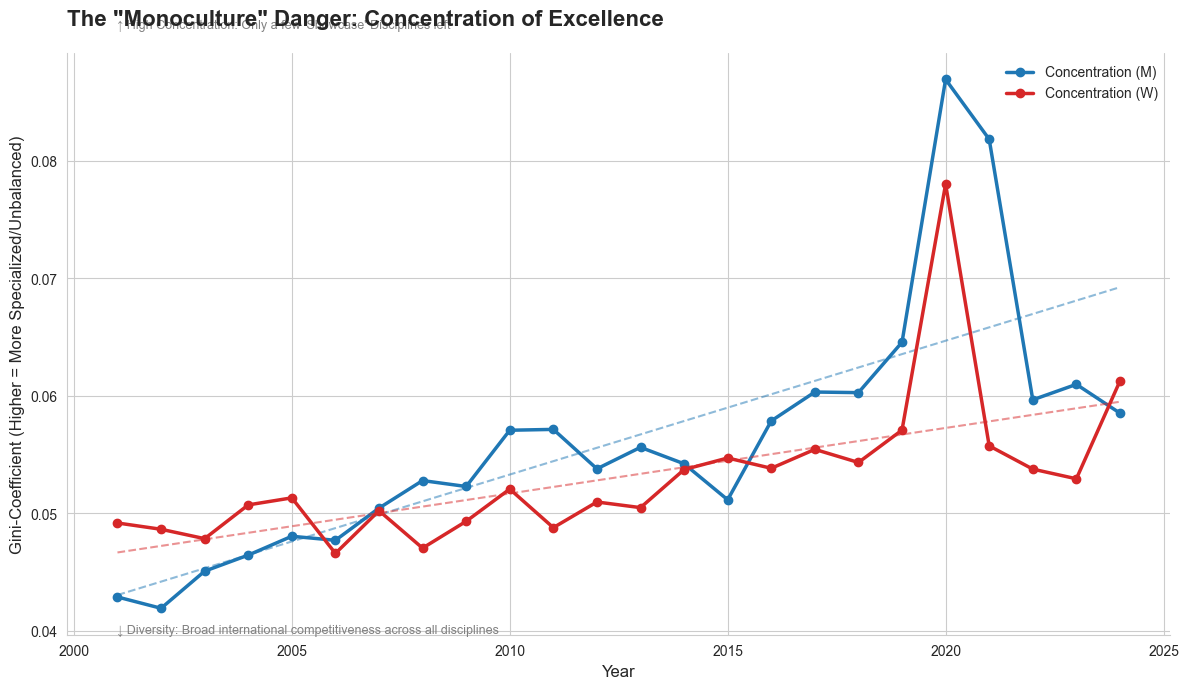

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def calculate_gini(x):
    """Berechnet den Gini-Koeffizienten einer Verteilung."""
    # x muss sortiert sein
    n = len(x)
    if n == 0: return 0
    # Berechnung der relativen mittleren absoluten Differenz
    return (np.abs(np.subtract.outer(x, x)).mean()) / (2 * np.mean(x))

def plot_discipline_concentration(df):
    # 1. Datenvorbereitung
    df_gini = df.copy()
    df_gini['iaaf_score'] = pd.to_numeric(df_gini['iaaf_score'], errors='coerce')
    df_gini = df_gini.dropna(subset=['iaaf_score'])
    
    # Fokus auf die Top 5 pro Disziplin pro Jahr (um die Spitze zu messen)
    # Wir schauen, wie ungleich die Qualität der Spitzen über die Disziplinen verteilt ist
    top_performances = df_gini[df_gini['altersklasse'].isin(['Maenner', 'Frauen'])].groupby(
        ['jahr', 'disziplin', 'geschlecht']
    )['iaaf_score'].mean().reset_index()

    # 2. Gini-Koeffizient pro Jahr berechnen
    # Wir gruppieren nach Jahr und Geschlecht und schauen, wie ungleich die Scores der Disziplinen sind
    annual_concentration = top_performances.groupby(['jahr', 'geschlecht'])['iaaf_score'].apply(
        lambda x: calculate_gini(x.values)
    ).reset_index(name='gini_index')

    # 3. Visualisierung
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Plot für Männer und Frauen
    colors = {'M': '#1f77b4', 'W': '#d62728'}
    for g in ['M', 'W']:
        subset = annual_concentration[annual_concentration['geschlecht'] == g]
        plt.plot(subset['jahr'], subset['gini_index'], 
                 label=f'Concentration ({g})', color=colors[g], marker='o', linewidth=2.5)
        
        # Trendlinie hinzufügen
        z = np.polyfit(subset['jahr'], subset['gini_index'], 1)
        p = np.poly1d(z)
        plt.plot(subset['jahr'], p(subset['jahr']), linestyle='--', alpha=0.5, color=colors[g])

    # Optik
    plt.title('The "Monoculture" Danger: Concentration of Excellence', 
              fontsize=16, fontweight='bold', loc='left', pad=20)
    plt.ylabel('Gini-Coefficient (Higher = More Specialized/Unbalanced)', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    
    # Interpretations-Hilfe
    plt.text(2001, annual_concentration['gini_index'].max() * 1.05, 
             "↑ High Concentration: Only a few 'Showcase' Disciplines left", color='gray', fontsize=9)
    plt.text(2001, annual_concentration['gini_index'].min() * 0.95, 
             "↓ Diversity: Broad international competitiveness across all disciplines", color='gray', fontsize=9)

    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return annual_concentration
# Aufruf
concentration_results = plot_discipline_concentration(df)


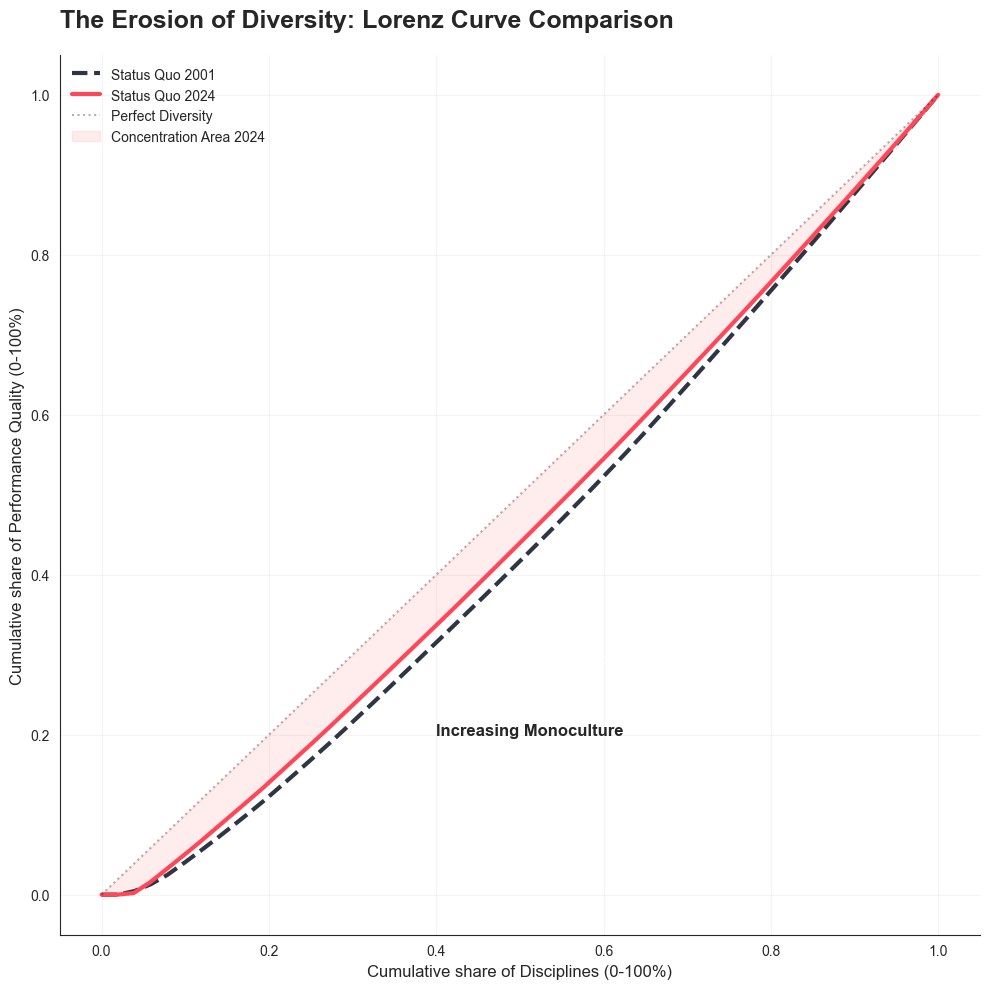

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_lorenz_comparison(df, year_start=2001, year_end=2024):
    # 1. Datenvorbereitung
    df_lorenz = df.copy()
    df_lorenz['iaaf_score'] = pd.to_numeric(df_lorenz['iaaf_score'], errors='coerce')
    df_lorenz = df_lorenz.dropna(subset=['iaaf_score'])
    
    # Wir nehmen die Top 3 Mittelwerte pro Disziplin als Maßstab für die "Güte" der Disziplin
    def get_discipline_quality(data, year):
        data_year = data[(data['jahr'] == year) & (data['altersklasse'].isin(['Maenner', 'Frauen']))]
        quality = data_year.groupby(['disziplin', 'geschlecht'])['iaaf_score'].mean().sort_values().values
        return quality

    # 2. Lorenz-Kurven Funktion
    def lorenz_values(values):
        scaled_values = values - values.min() + 1 # Wir schauen uns die Varianz ÜBER dem Minimum an
        n = len(scaled_values)
        lorenz = np.cumsum(np.sort(scaled_values)) / scaled_values.sum()
        return np.insert(lorenz, 0, 0)

    plt.figure(figsize=(10, 10))
    sns.set_style("white")

    for year, color, ls in [(year_start, '#2f3542', '--'), (year_end, '#ff4757', '-')]:
        # Wir aggregieren hier über beide Geschlechter für das Gesamtbild des Verbands
        vals = get_discipline_quality(df_lorenz, year)
        lorenz = lorenz_values(vals)
        x_axis = np.linspace(0, 1, len(lorenz))
        
        plt.plot(x_axis, lorenz, label=f'Status Quo {year}', color=color, linewidth=3, linestyle=ls)

    # Die ideale Diagonale (Theoretische totale Vielfalt)
    plt.plot([0, 1], [0, 1], color='black', alpha=0.3, linestyle=':', label='Perfect Diversity')

    # Visualisierung des "Gaps" (Die Fläche zwischen den Kurven ist die Zunahme der Monokultur)
    plt.fill_between(np.linspace(0, 1, len(lorenz)), lorenz, np.linspace(0, 1, len(lorenz)), 
                     color='#ff4757', alpha=0.1, label='Concentration Area 2024')

    # Styling
    plt.title('The Erosion of Diversity: Lorenz Curve Comparison', fontsize=18, fontweight='bold', loc='left', pad=20)
    plt.xlabel('Cumulative share of Disciplines (0-100%)', fontsize=12)
    plt.ylabel('Cumulative share of Performance Quality (0-100%)', fontsize=12)
    
    # Annotationen
    plt.annotate('Increasing Monoculture', xy=(0.7, 0.4), xytext=(0.4, 0.2),
                 arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12, fontweight='bold')

    plt.legend(frameon=False, loc='upper left')
    plt.grid(alpha=0.2)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Aufruf
plot_lorenz_comparison(df)

#### Drop Out der U23 Athleten (alle Athleten)

<Figure size 1200x800 with 0 Axes>

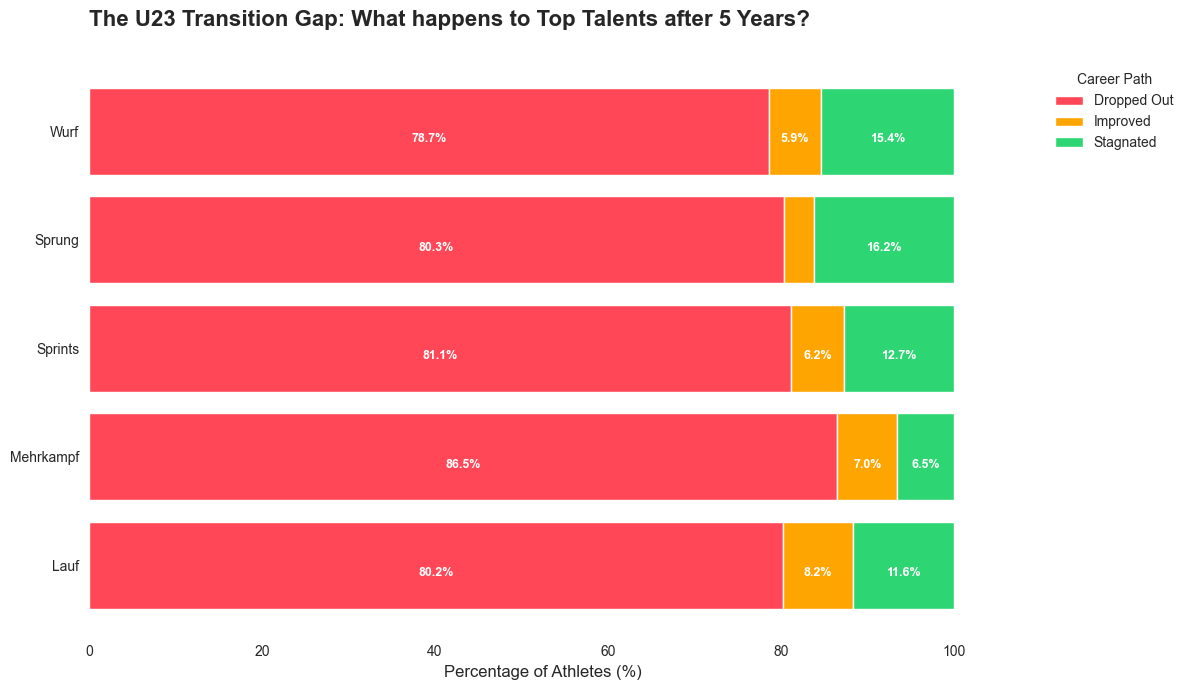

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_u23_transition_leakage(df):
    # 1. Datenvorbereitung
    df_u23 = df.copy()
    df_u23['iaaf_score'] = pd.to_numeric(df_u23['iaaf_score'], errors='coerce')
    df_u23 = df_u23.dropna(subset=['iaaf_score', 'name'])

    # Spektren Definition
    spectra = {
        "Sprints": ["100 m", "200 m", "400 m", "100 m Hürden", "110 m Hürden"],
        "Lauf": ["800 m", "1500 m", "5000 m", "3000 m Hindernis"],
        "Wurf": ["Speerwurf", "Diskuswurf", "Kugelstoßen", "Hammerwurf"],
        "Sprung": ["Weitsprung", "Hochsprung", "Stabhochsprung", "Dreisprung"],
        "Mehrkampf": ["Zehnkampf", "Siebenkampf"]
    }

    # 2. Transition-Logik: Tracking von Kohorten
    # Wir nehmen U23-Top-Athleten (z.B. Jahr 2015-2018) und schauen wo sie 5 Jahre später stehen
    transition_results = []

    for spectrum, disc_list in spectra.items():
        df_spec = df_u23[df_u23['disziplin'].isin(disc_list)]
        
        # Kohorte: Alle, die zwischen 2010 und 2019 in der U23 waren
        u23_talents = df_spec[df_spec['altersklasse'] == 'U23'].groupby('name').agg({
            'jahr': 'min', 'iaaf_score': 'max'
        }).reset_index()

        for _, talent in u23_talents.iterrows():
            # Status 5 Jahre nach dem ersten U23-Eintrag prüfen
            target_year = talent['jahr'] + 5
            later_perf = df_spec[(df_spec['name'] == talent['name']) & 
                                 (df_spec['jahr'] == target_year) & 
                                 (df_spec['altersklasse'].isin(['Maenner', 'Frauen']))]
            
            if not later_perf.empty:
                score_diff = later_perf['iaaf_score'].max() - talent['iaaf_score']
                status = 'Improved' if score_diff > 0 else 'Stagnated'
            else:
                status = 'Dropped Out'
                score_diff = np.nan
            
            transition_results.append({'Spectrum': spectrum, 'Status': status, 'Diff': score_diff})

    results_df = pd.DataFrame(transition_results)

    # 3. Visualisierung: Gestapeltes Barchart (Prozentuale Verteilung)
    pivot_df = results_df.groupby(['Spectrum', 'Status']).size().unstack().fillna(0)
    pivot_df_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

    # Sleek Plotting
    plt.figure(figsize=(12, 8))
    colors = ['#ff4757', '#ffa502', '#2ed573'] # Dropped Out (Rot), Stagnated (Gelb), Improved (Grün)
    
    ax = pivot_df_pct.plot(kind='barh', stacked=True, color=colors, figsize=(12, 7), width=0.8)

    # Styling
    plt.title('The U23 Transition Gap: What happens to Top Talents after 5 Years?', 
              fontsize=16, fontweight='bold', loc='left', pad=25)
    plt.xlabel('Percentage of Athletes (%)', fontsize=12)
    plt.ylabel('')
    plt.legend(title="Career Path", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    
    # Werte in die Balken schreiben
    for p in ax.patches:
        width = p.get_width()
        if width > 5:
            ax.annotate(f'{width:.1f}%', (p.get_x() + width/2, p.get_y() + 0.3), 
                        ha='center', color='white', fontweight='bold', fontsize=9)

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

# Aufruf
plot_u23_transition_leakage(df)

<Figure size 1200x800 with 0 Axes>

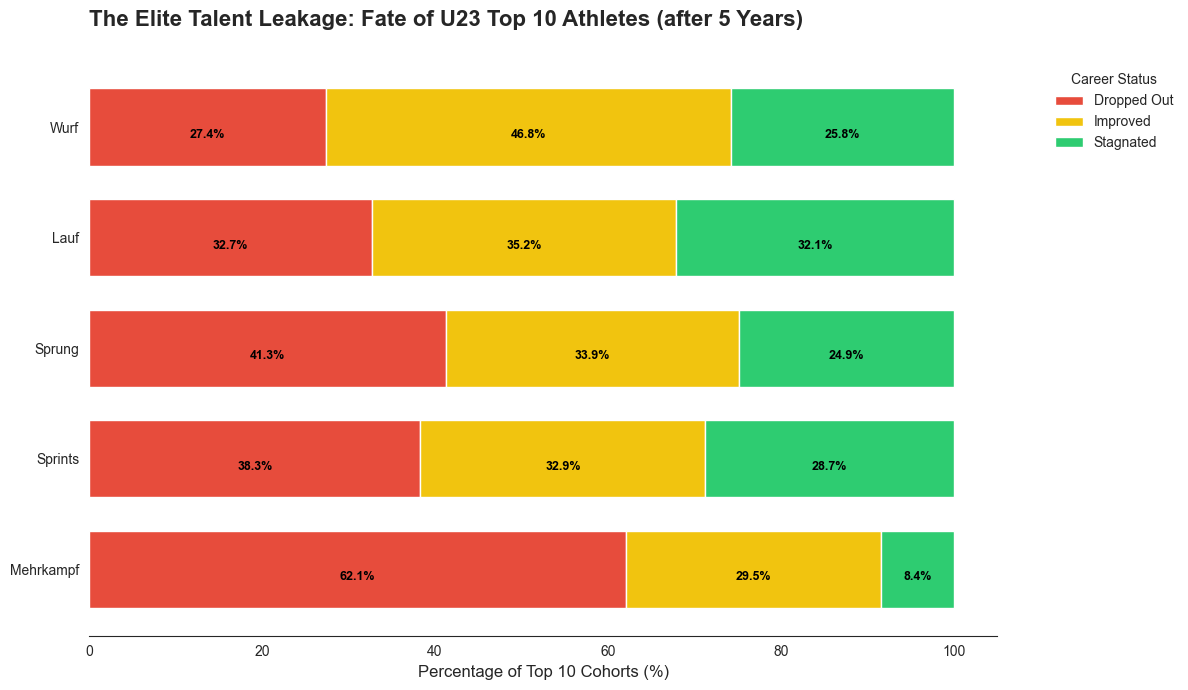

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_u23_top10_transition(df):
    # 1. Datenvorbereitung
    df_u23 = df.copy()
    df_u23['iaaf_score'] = pd.to_numeric(df_u23['iaaf_score'], errors='coerce')
    df_u23 = df_u23.dropna(subset=['iaaf_score', 'name'])

    spectra = {
        "Sprints": ["100 m", "200 m", "400 m", "100 m Hürden", "110 m Hürden"],
        "Lauf": ["800 m", "1500 m", "5000 m", "3000 m Hindernis"],
        "Wurf": ["Speerwurf", "Diskuswurf", "Kugelstoßen", "Hammerwurf"],
        "Sprung": ["Weitsprung", "Hochsprung", "Stabhochsprung", "Dreisprung"],
        "Mehrkampf": ["Zehnkampf", "Siebenkampf"]
    }

    transition_results = []

    # 2. Top 10 Filter & Tracking
    for spectrum, disc_list in spectra.items():
        df_spec = df_u23[df_u23['disziplin'].isin(disc_list)]
        
        # Wir gehen jahrweise vor, um die jeweiligen Top 10 der U23 zu finden
        for year in range(df_spec['jahr'].min(), df_spec['jahr'].max() - 4):
            # Finde die Top 10 U23-Athleten dieses Jahres
            top_10_names = df_spec[(df_spec['jahr'] == year) & 
                                   (df_spec['altersklasse'] == 'U23')
                                  ].sort_values('iaaf_score', ascending=False).head(10)['name'].unique()
            
            for name in top_10_names:
                # Ausgangswert (Bestleistung im U23 Jahr)
                u23_best = df_spec[(df_spec['name'] == name) & (df_spec['jahr'] == year)]['iaaf_score'].max()
                
                # Check 5 Jahre später
                target_year = year + 5
                later_perf = df_spec[(df_spec['name'] == name) & 
                                     (df_spec['jahr'] == target_year) & 
                                     (df_spec['altersklasse'].isin(['Maenner', 'Frauen']))]
                
                if not later_perf.empty:
                    score_diff = later_perf['iaaf_score'].max() - u23_best
                    status = 'Improved' if score_diff > 0 else 'Stagnated'
                else:
                    status = 'Dropped Out'
                
                transition_results.append({'Spectrum': spectrum, 'Status': status, 'Year': year})

    results_df = pd.DataFrame(transition_results)

    # 3. Aggregation und Visualisierung
    pivot_df = results_df.groupby(['Spectrum', 'Status']).size().unstack().fillna(0)
    pivot_df_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

    # Sortierung für bessere Optik (Wurf meist oben, da stabiler)
    pivot_df_pct = pivot_df_pct.sort_values('Improved', ascending=True)

    plt.figure(figsize=(12, 8))
    colors = ['#e74c3c', '#f1c40f', '#2ecc71'] # Rot, Gelb, Grün
    
    ax = pivot_df_pct.plot(kind='barh', stacked=True, color=colors, figsize=(12, 7), width=0.7)

    # Styling & Labels
    plt.title('The Elite Talent Leakage: Fate of U23 Top 10 Athletes (after 5 Years)', 
              fontsize=16, fontweight='bold', loc='left', pad=25)
    plt.xlabel('Percentage of Top 10 Cohorts (%)', fontsize=12)
    plt.ylabel('')
    
    # Werte einzeichnen
    for p in ax.patches:
        width = p.get_width()
        if width > 5:
            ax.annotate(f'{width:.1f}%', (p.get_x() + width/2, p.get_y() + 0.25), 
                        ha='center', color='black', fontweight='bold', fontsize=9)

    plt.legend(title="Career Status", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

# Aufruf
plot_u23_top10_transition(df)

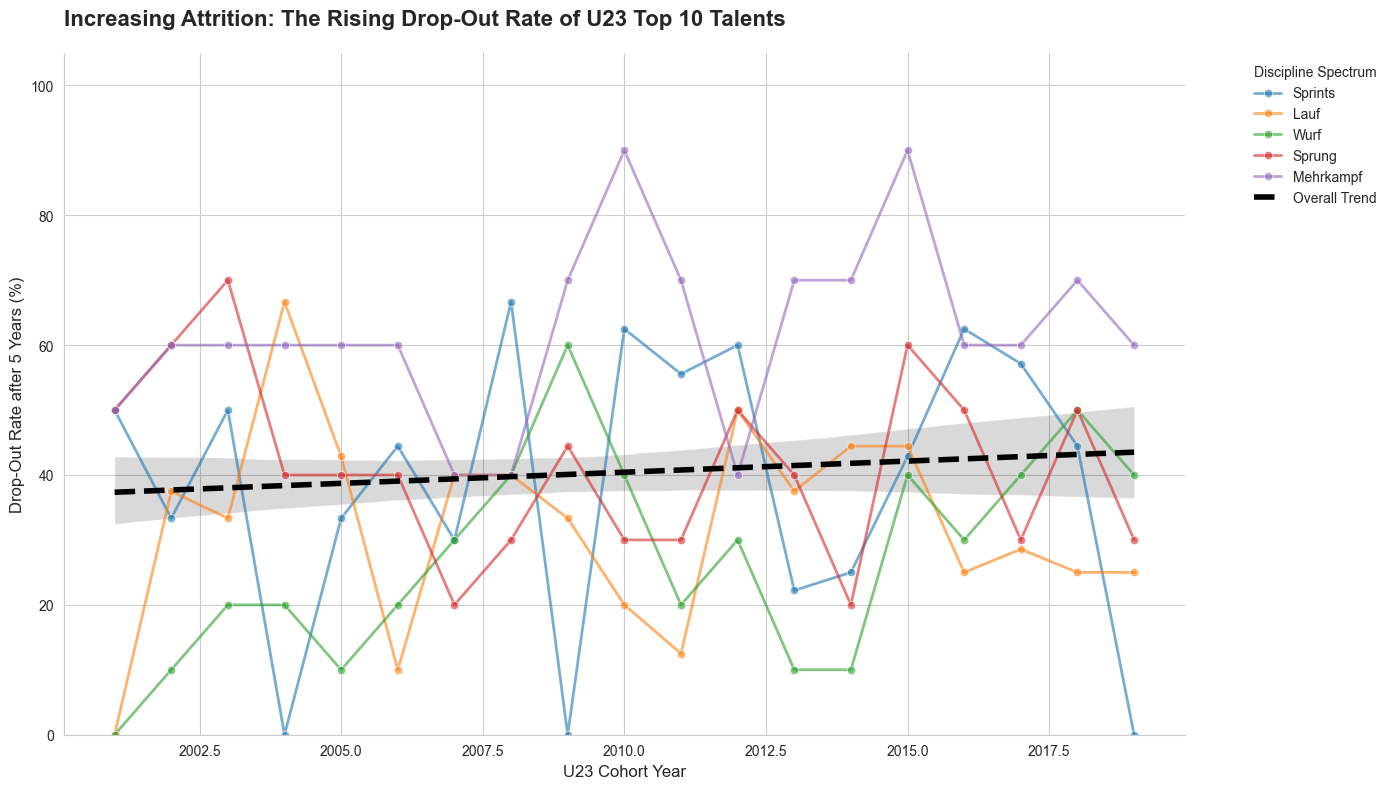

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_dropout_trend(df):
    # 1. Datenvorbereitung
    df_trend = df.copy()
    df_trend['iaaf_score'] = pd.to_numeric(df_trend['iaaf_score'], errors='coerce')
    df_trend = df_trend.dropna(subset=['iaaf_score', 'name'])

    spectra = {
        "Sprints": ["100 m", "200 m", "400 m", "100 m Hürden", "110 m Hürden"],
        "Lauf": ["800 m", "1500 m", "5000 m", "3000 m Hindernis"],
        "Wurf": ["Speerwurf", "Diskuswurf", "Kugelstoßen", "Hammerwurf"],
        "Sprung": ["Weitsprung", "Hochsprung", "Stabhochsprung", "Dreisprung"],
        "Mehrkampf": ["Zehnkampf", "Siebenkampf"]
    }

    trend_records = []

    # 2. Jahr-für-Jahr Analyse der Drop-Out-Quote
    # Wir enden 5 Jahre vor dem aktuellen Datensatz-Ende
    max_year = df_trend['jahr'].max() - 5
    
    for spectrum, disc_list in spectra.items():
        df_spec = df_trend[df_trend['disziplin'].isin(disc_list)]
        
        for year in range(2001, max_year + 1):
            # Top 10 U23 Namen des aktuellen Jahres
            top_10 = df_spec[(df_spec['jahr'] == year) & 
                             (df_spec['altersklasse'] == 'U23')
                            ].sort_values('iaaf_score', ascending=False).head(10)
            
            if top_10.empty: continue
            
            top_10_names = top_10['name'].unique()
            total_talents = len(top_10_names)
            
            # Check wer 5 Jahre später noch aktiv ist
            target_year = year + 5
            later_active = df_spec[(df_spec['name'].isin(top_10_names)) & 
                                   (df_spec['jahr'] == target_year)]['name'].nunique()
            
            dropout_rate = (1 - (later_active / total_talents)) * 100
            
            trend_records.append({
                'Year': year, 
                'Spectrum': spectrum, 
                'Dropout_Rate': dropout_rate
            })

    trend_df = pd.DataFrame(trend_records)

    # 3. Visualisierung
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # Linienplot mit Regressions-Trend
    sns.lineplot(data=trend_df, x='Year', y='Dropout_Rate', hue='Spectrum', 
                 marker='o', alpha=0.6, linewidth=2)
    
    # Globaler Trend (fett markiert)
    global_trend = trend_df.groupby('Year')['Dropout_Rate'].mean().reset_index()
    sns.regplot(data=global_trend, x='Year', y='Dropout_Rate', scatter=False, 
                color='black', label='Overall Trend', line_kws={"linewidth": 4, "linestyle": "--"})

    # Design-Feinschliff
    plt.title('Increasing Attrition: The Rising Drop-Out Rate of U23 Top 10 Talents', 
              fontsize=16, fontweight='bold', loc='left', pad=20)
    plt.ylabel('Drop-Out Rate after 5 Years (%)', fontsize=12)
    plt.xlabel('U23 Cohort Year', fontsize=12)
    plt.ylim(0, 105)
    
    # Interpretation

    plt.legend(title="Discipline Spectrum", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Aufruf
plot_dropout_trend(df)

#### Fragilitätsindex

1. Age Risk (Alters-Struktur)
Messgröße: Durchschnittsalter der nationalen Top 3 (Männer/Frauen).
Berechnung: Skalierung von 24 Jahren (Risk=0) bis 32 Jahre (Risk=1).
Aussage: Misst das „Ablaufdatum“ der aktuellen Leistungsträger; zeigt an, wann eine Disziplin ihre biologische Spitze verliert.

2. Succession Risk (Nachwuchs-Gap)
Messgröße: Punkte-Differenz (IAAF Score) zwischen Elite-Top-3 und U23-Top-3.
Berechnung: Lineare Skalierung (0 Punkte = 0; 150 Punkte = 1).
Aussage: Misst die Tiefe des „Fallschirms“; ein hoher Wert bedeutet, dass bei Rücktritten der Stars ein massives Leistungsloch entsteht.

3. Monoculture Risk (Vereins-Konzentration)
Messgröße: Prozentualer Anteil des dominantesten Vereins an den nationalen Top 10.
Berechnung: Skalierung von 20 % Vereinsanteil (0) bis 80 % Anteil (1).
Aussage: Misst die strukturelle Abhängigkeit; zeigt, wie anfällig eine Disziplin für den Wegfall einzelner Trainer oder Stützpunkte ist.

4. Gesamt-Index (Total Fragility)
Gewichtung: 40%Age+40%Gap+20%Club.
Interpretation:
0.0 – 0.3 (Grün): Stabil; gesunder Übergang von U23 zu Elite.
0.4 – 0.6 (Gelb): Gefährdet; Nachwuchs- oder Altersprobleme erkennbar.
#> 0.7 (Rot): Kritisch; drohender Kollaps der Disziplin in naher Zukunft.

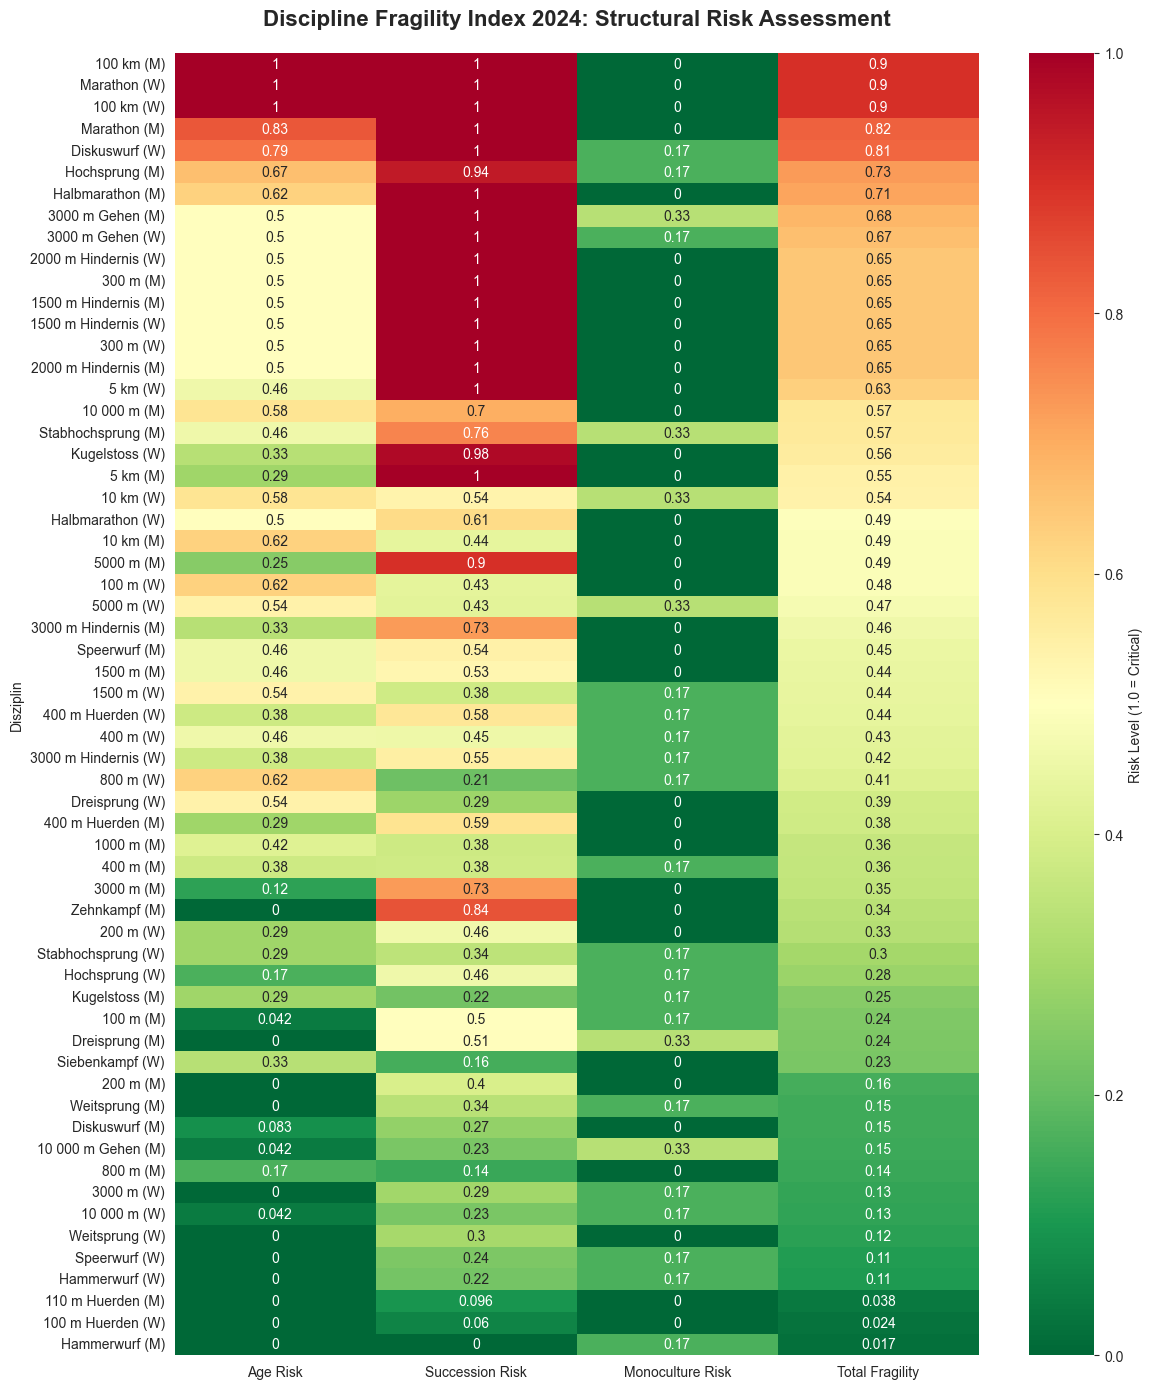

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_fragility_index(df, target_year=2024):
    # 1. Datenvorbereitung
    df_idx = df[df['jahr'] == target_year].copy()
    df_idx['iaaf_score'] = pd.to_numeric(df_idx['iaaf_score'], errors='coerce')
    df_idx['age'] = target_year - df_idx['geburtsjahr']
    
    results = []
    disciplines = df_idx['disziplin'].unique()

    for disc in disciplines:
        for gender in ['M', 'W']:
            subset = df_idx[(df_idx['disziplin'] == disc) & (df_idx['geschlecht'] == gender)]
            if subset.empty: continue
            
            # --- FAKTOR 1: Alters-Risiko (Top 3) ---
            top3_age = subset[subset['altersklasse'].isin(['Maenner', 'Frauen'])].nlargest(3, 'iaaf_score')['age'].mean()
            # Risiko-Skalierung: 24 Jahre = 0, 32 Jahre = 1
            age_risk = np.clip((top3_age - 24) / (32 - 24), 0, 1) if not np.isnan(top3_age) else 0.5

            # --- FAKTOR 2: Nachwuchs-Gap ---
            elite_perf = subset[subset['altersklasse'].isin(['Maenner', 'Frauen'])]['iaaf_score'].nlargest(3).mean()
            u23_perf = subset[subset['altersklasse'] == 'U23']['iaaf_score'].nlargest(3).mean()
            gap = elite_perf - u23_perf if (not np.isnan(elite_perf) and not np.isnan(u23_perf)) else 150
            # Risiko-Skalierung: 0 Punkte Gap = 0, 150 Punkte Gap = 1
            gap_risk = np.clip(gap / 150, 0, 1)

            # --- FAKTOR 3: Vereins-Monokultur ---
            # Wie viel % der Top 10 kommen aus dem dominantesten Verein?
            top10_clubs = subset.nlargest(10, 'iaaf_score')['verein']
            if not top10_clubs.empty:
                max_club_share = top10_clubs.value_counts().iloc[0] / len(top10_clubs)
                # Risiko-Skalierung: 20% (Breite) = 0, 80% (Abhängigkeit) = 1
                club_risk = np.clip((max_club_share - 0.2) / (0.8 - 0.2), 0, 1)
            else:
                club_risk = 0.5

            # Gesamt-Index (Gewichtet)
            total_index = (age_risk * 0.5) + (gap_risk * 0.4) + (club_risk * 0.1)
            
            results.append({
                'Disziplin': f"{disc} ({gender})",
                'Age Risk': age_risk,
                'Succession Risk': gap_risk,
                'Monoculture Risk': club_risk,
                'Total Fragility': total_index
            })

    # 2. Heatmap Erstellung
    fragility_df = pd.DataFrame(results).sort_values('Total Fragility', ascending=False)
    fragility_df = fragility_df.set_index('Disziplin')

    plt.figure(figsize=(12, 14))
    sns.heatmap(fragility_df, annot=True, cmap='RdYlGn_r', center=0.5, 
                cbar_kws={'label': 'Risk Level (1.0 = Critical)'})

    plt.title(f'Discipline Fragility Index {target_year}: Structural Risk Assessment', 
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

plot_fragility_index(df)

"final_Data_iaaf_scores_neu.csv" ist die datengrundlage für meine folgende idee: ich möchte zwei perioden vergleichen, 2001 bis 2004 und 2021 bis 2024. dabei interessiert mich die veränderung in dem durchschnitt, der standardabweichung, des medians, des tips und der differenz leistung platz 1 minus leistung platz 10. Es soll ein plot entstehen wie ein spinnennetzt. untersuche dabei nur männer und frauen (elite) einmal gesamt und einmal pro disziplintyp (kategorisiere die olympischen disziplinen mind. wurf, sprint, lauf). schreibe python skript dafür

Aktuelles Verzeichnis: /Users/erik/Library/CloudStorage/OneDrive-Persönlich/Tübingen Studium/1. Semester/Data Literacy/Project/Data-Literacy/data_csv


/var/folders/m8/s7c4nfhn7sq9nfvj431vg00w0000gn/T/ipykernel_38113/421361193.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m_old = data_all[data_all['jahr'].between(2001, 2004)].groupby(['disziplingruppe', 'geschlecht', 'altersklasse']).apply(get_radar_metrics).dropna()
/var/folders/m8/s7c4nfhn7sq9nfvj431vg00w0000gn/T/ipykernel_38113/421361193.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m_new = data_all

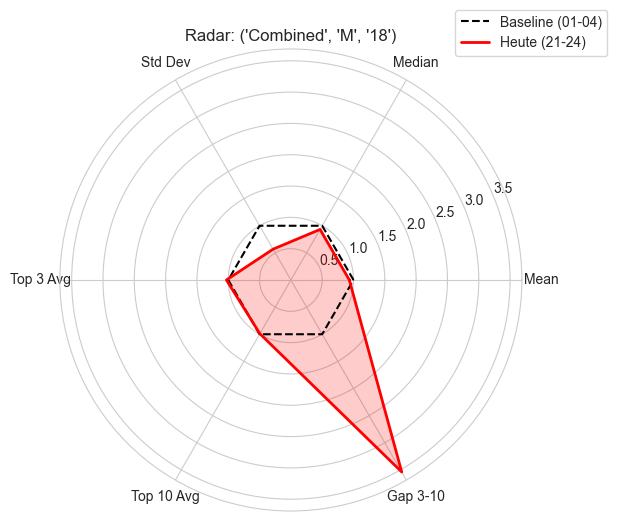

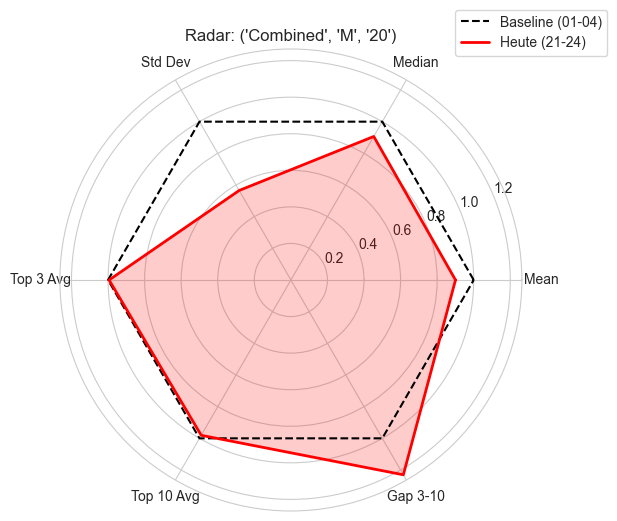

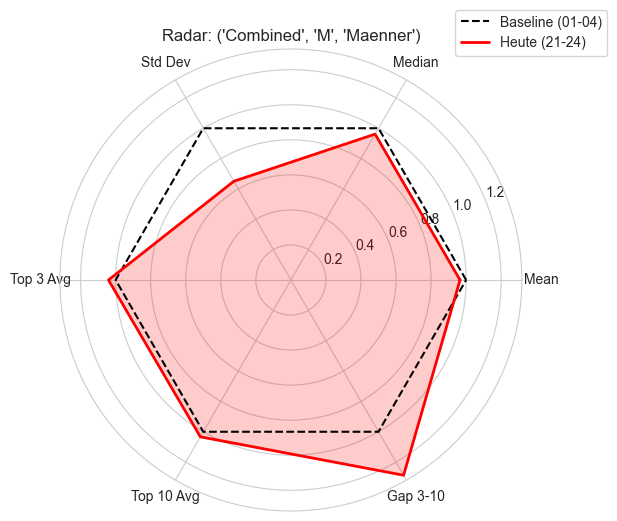

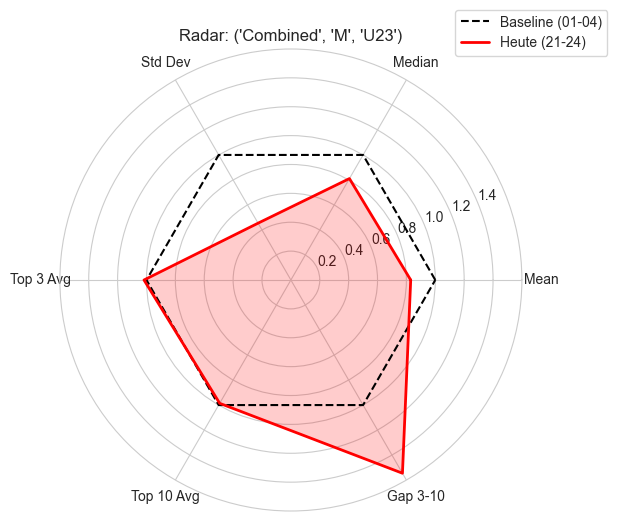

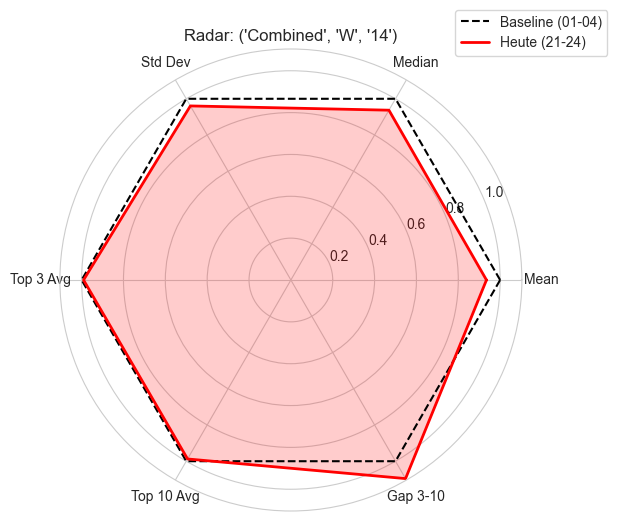

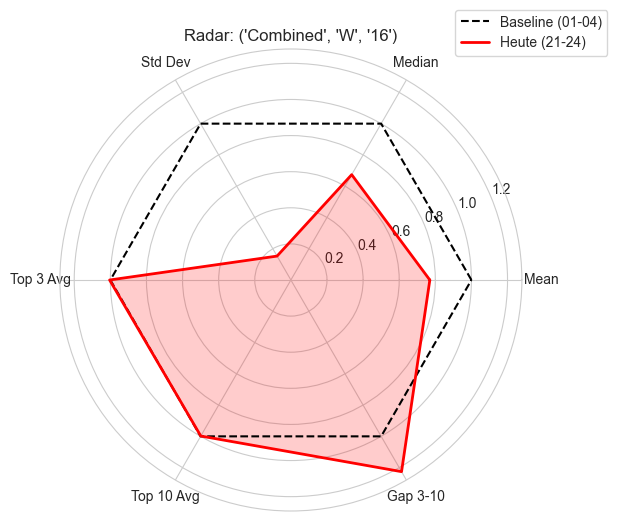

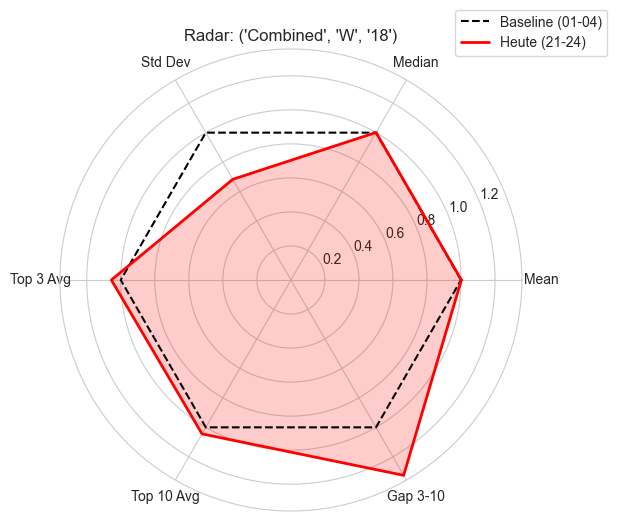

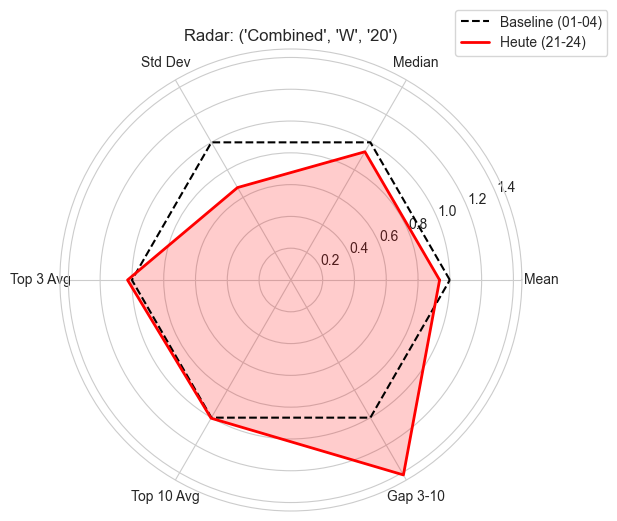

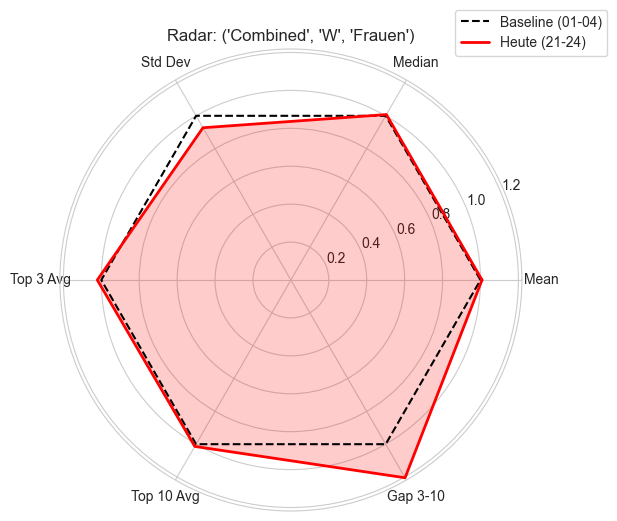

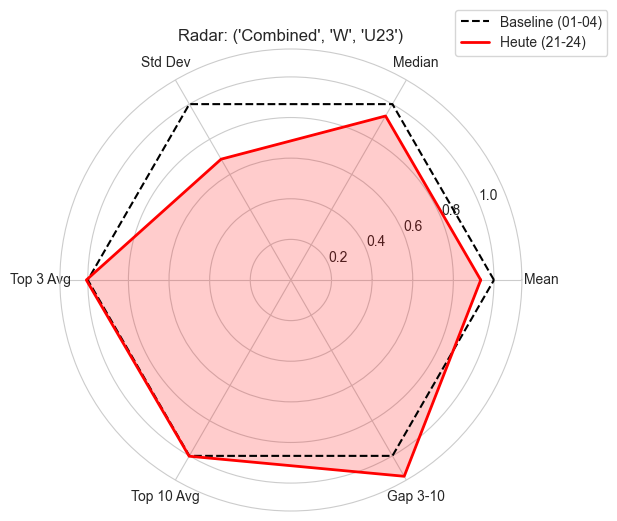

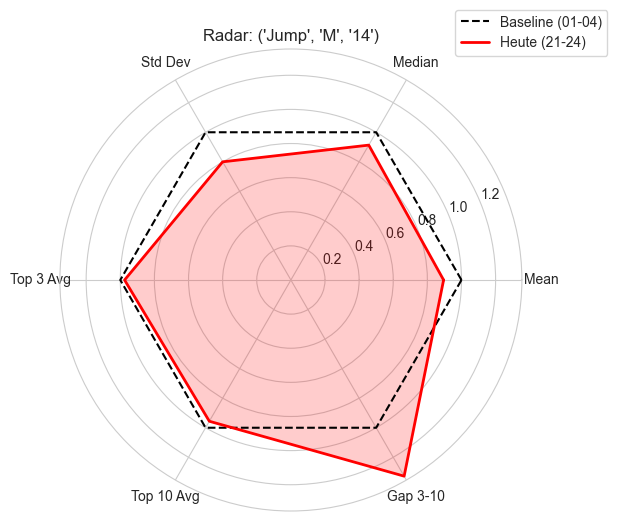

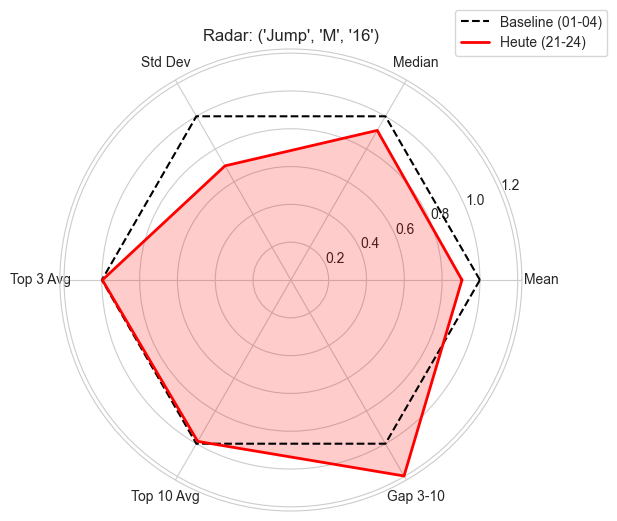

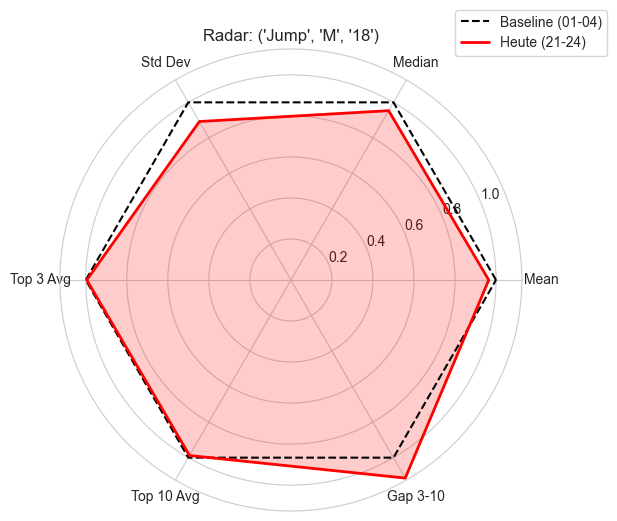

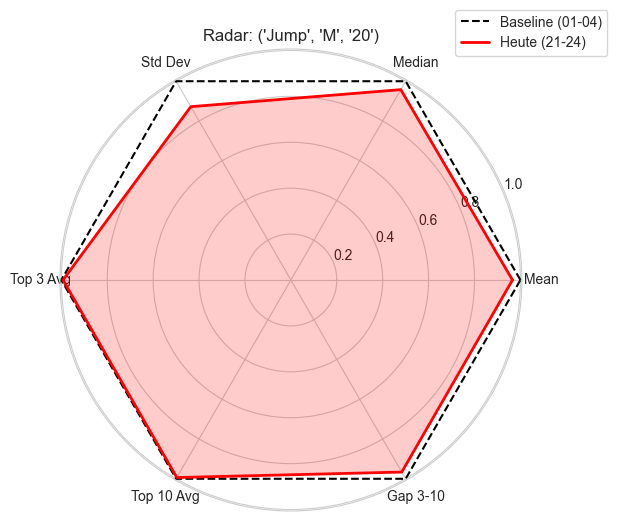

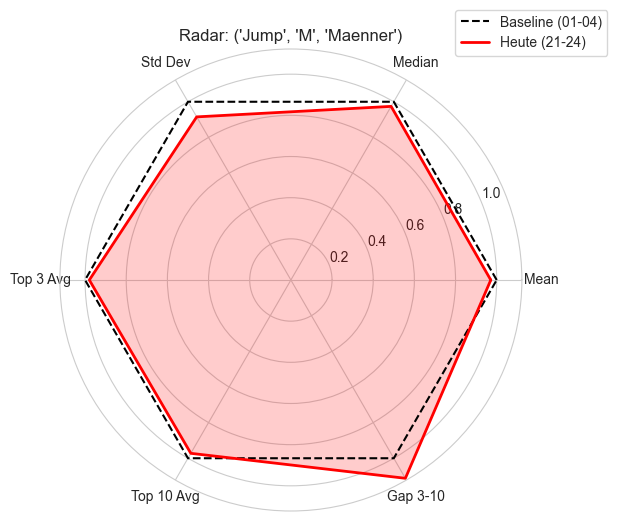

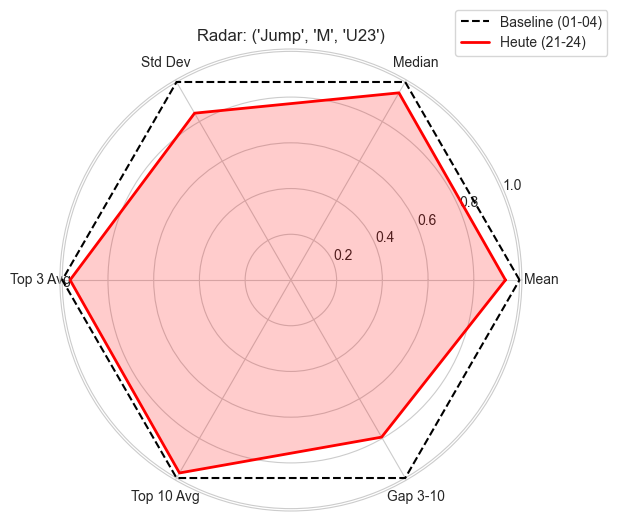

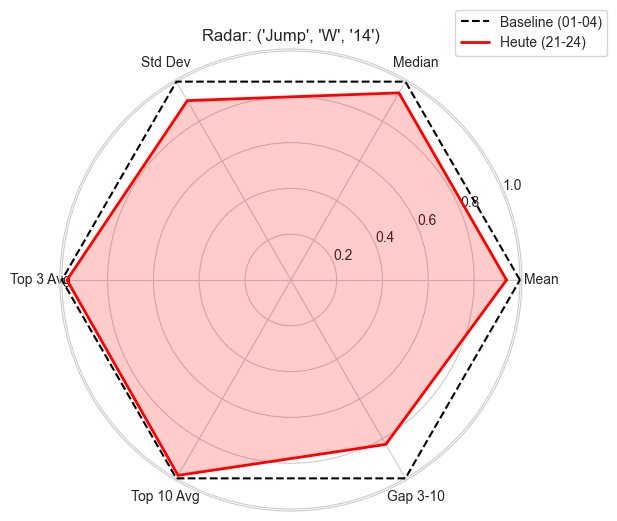

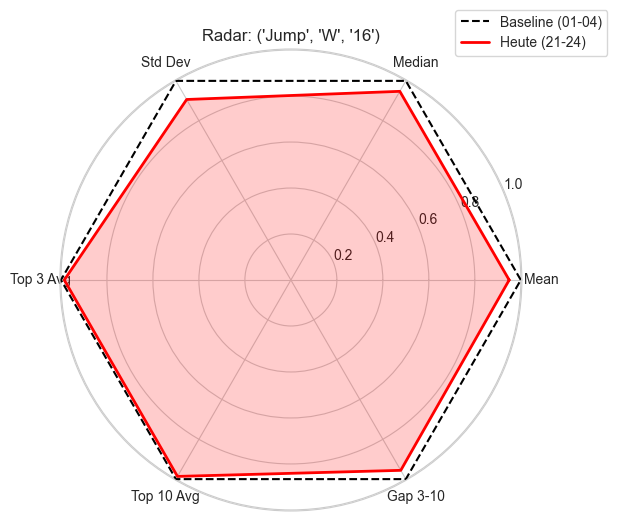

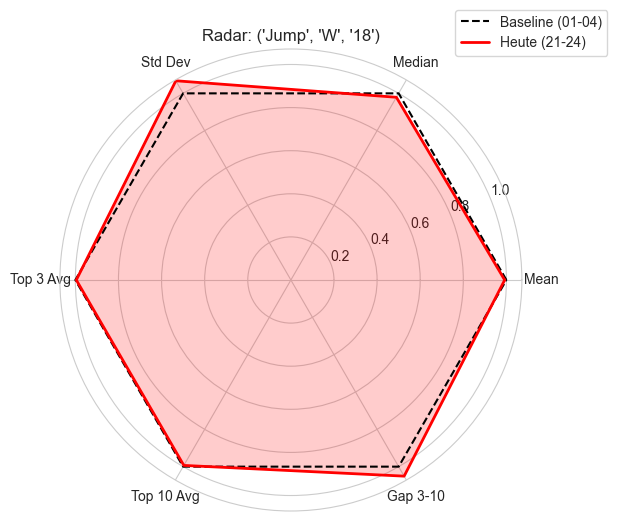

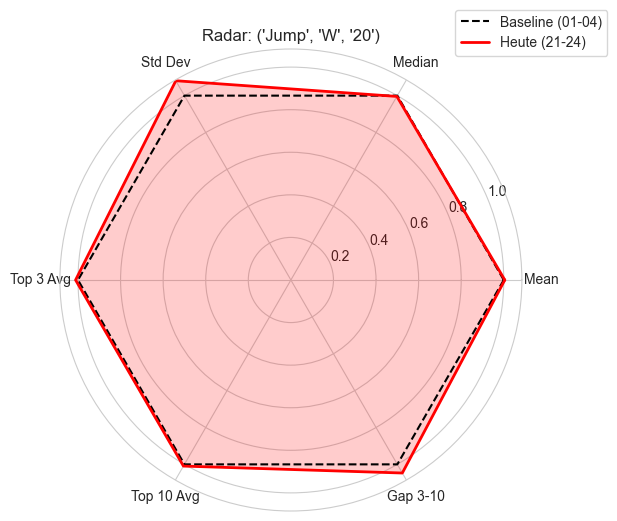

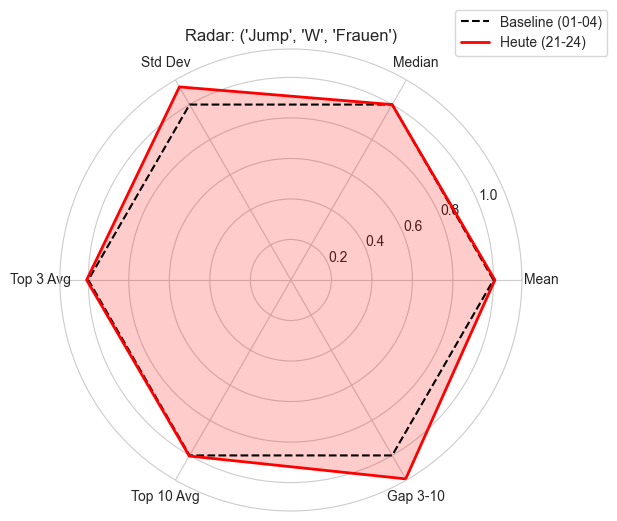

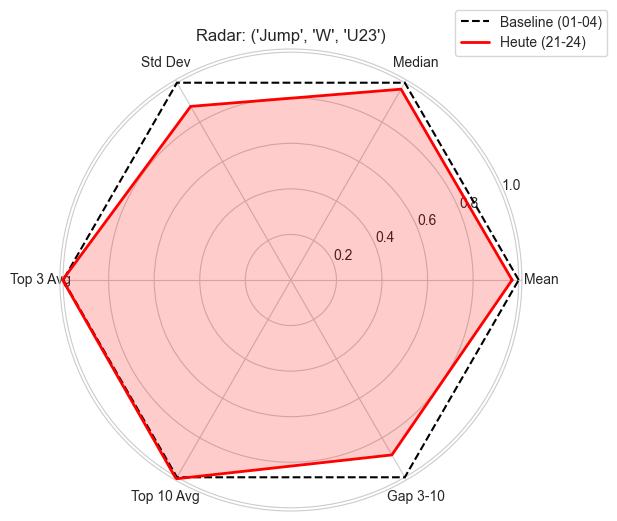

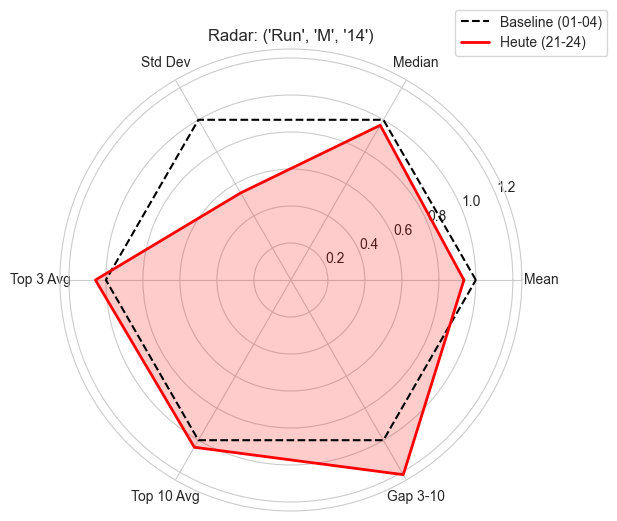

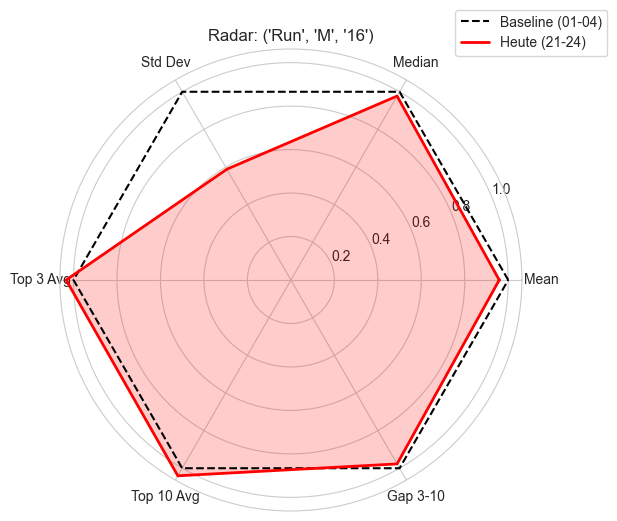

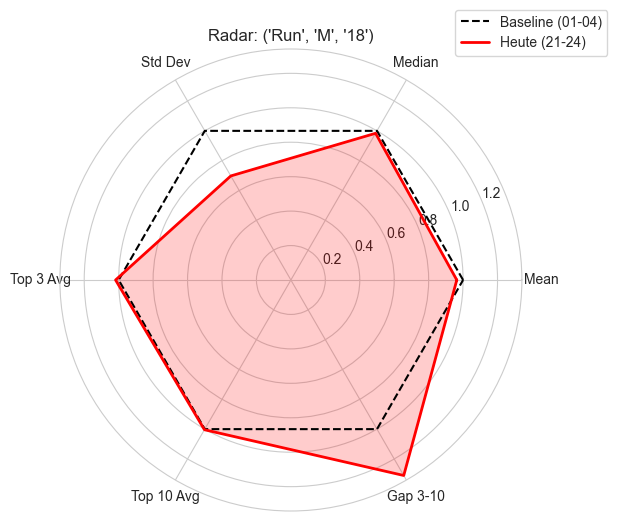

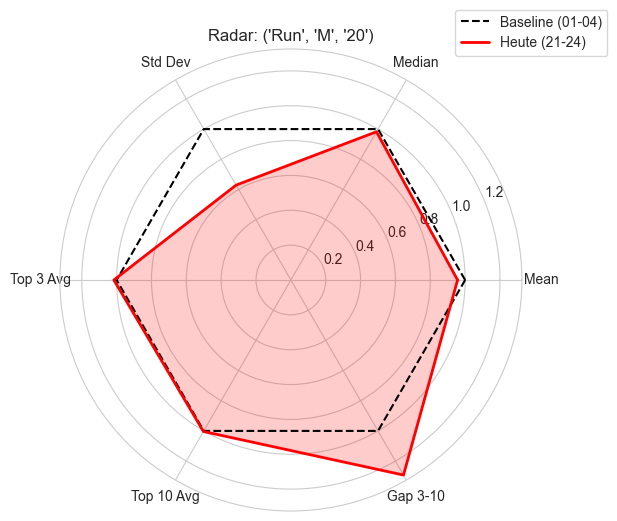

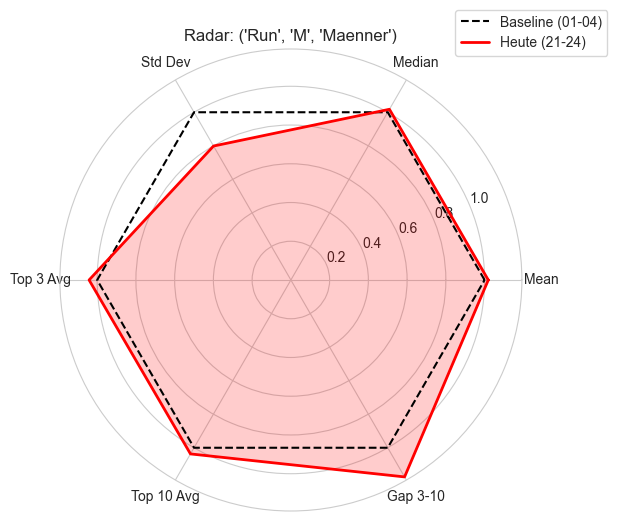

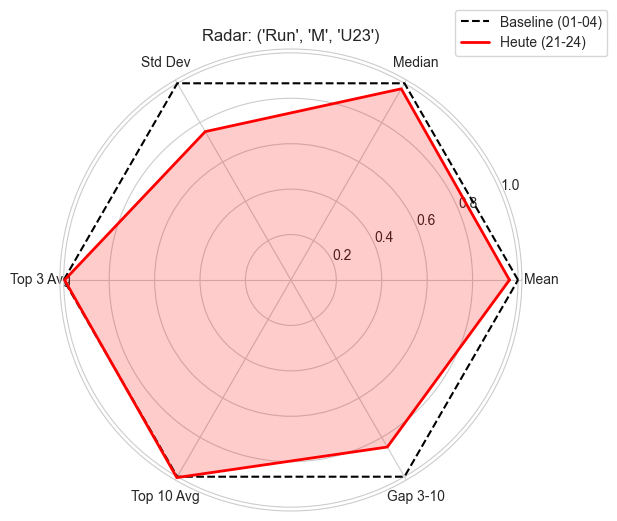

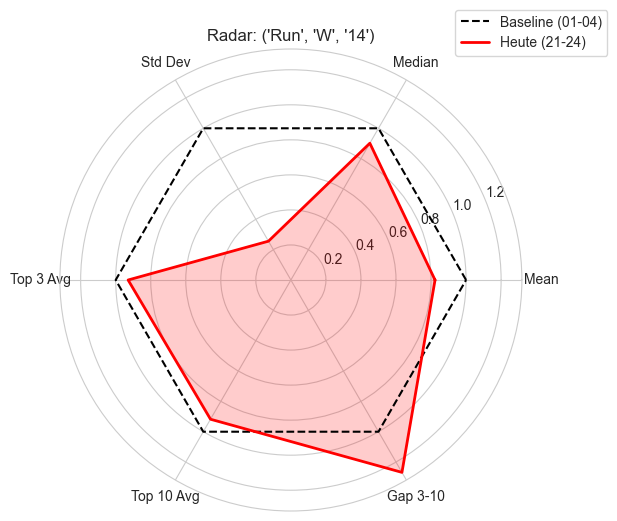

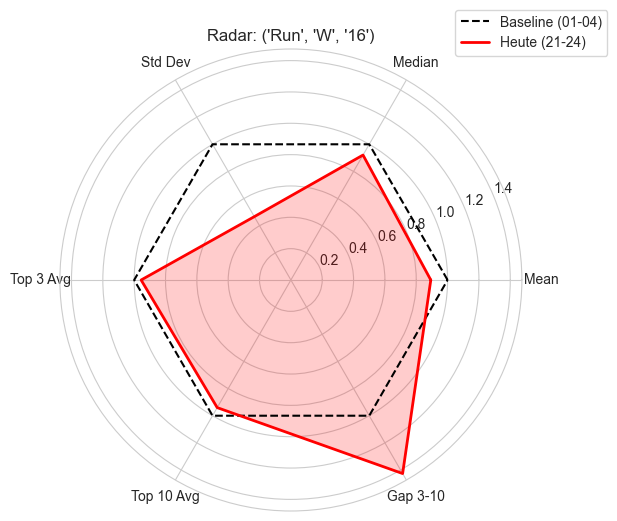

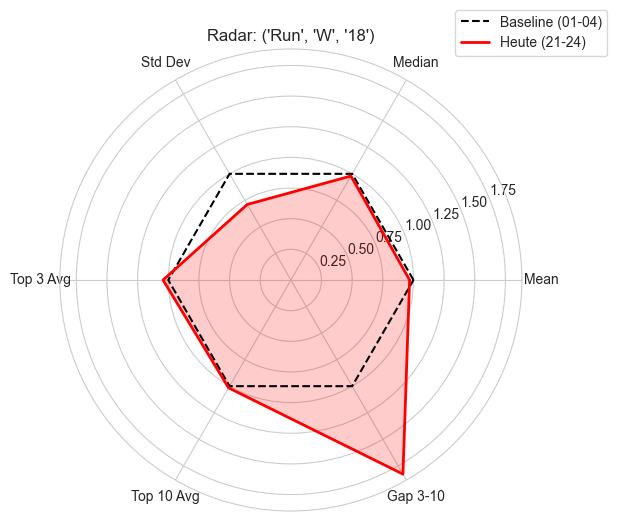

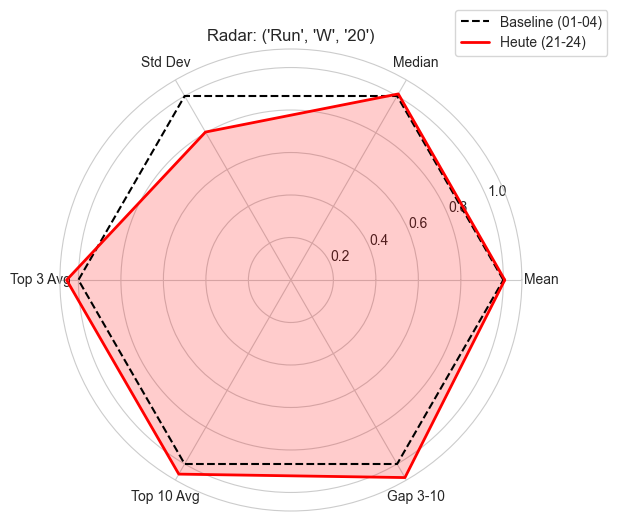

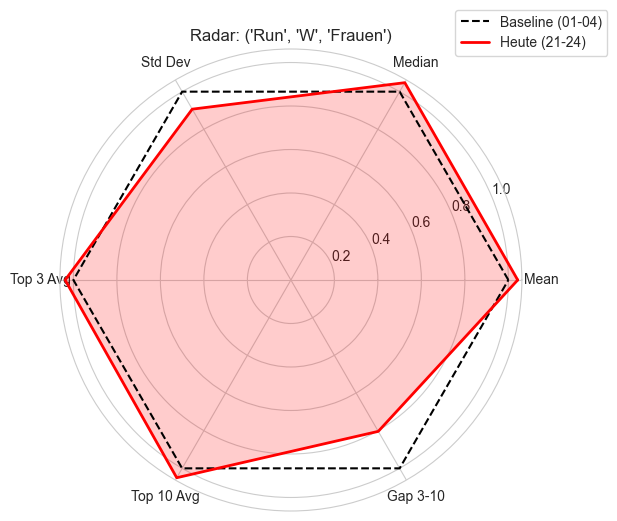

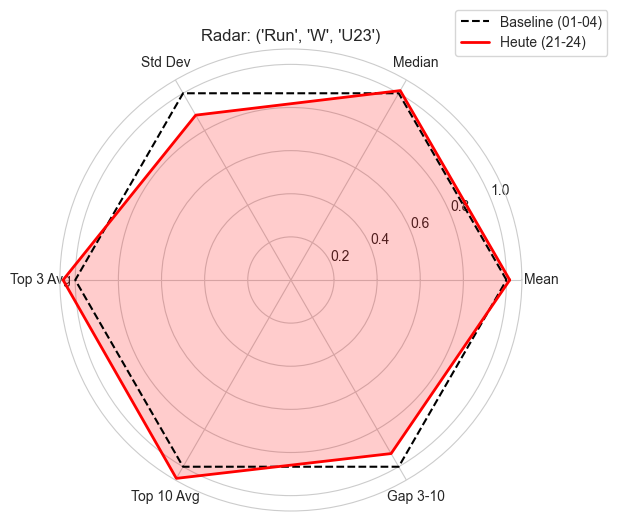

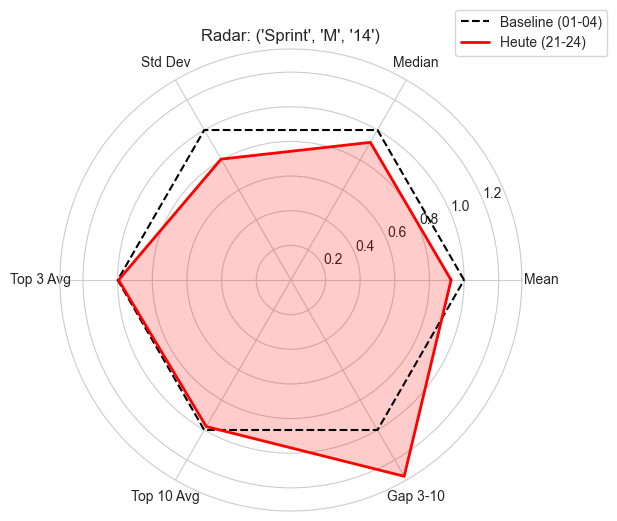

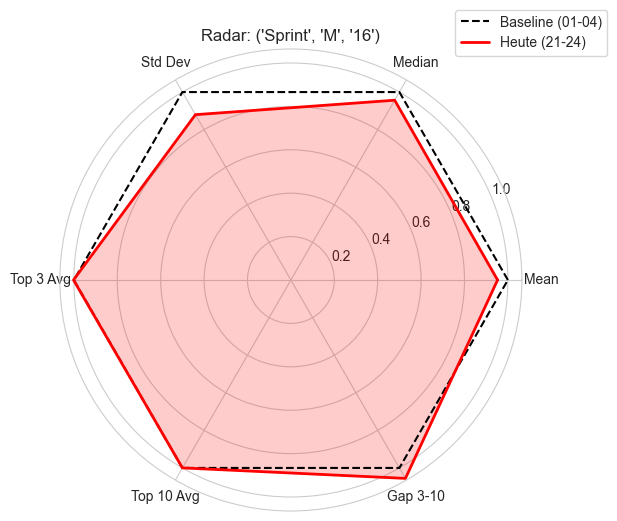

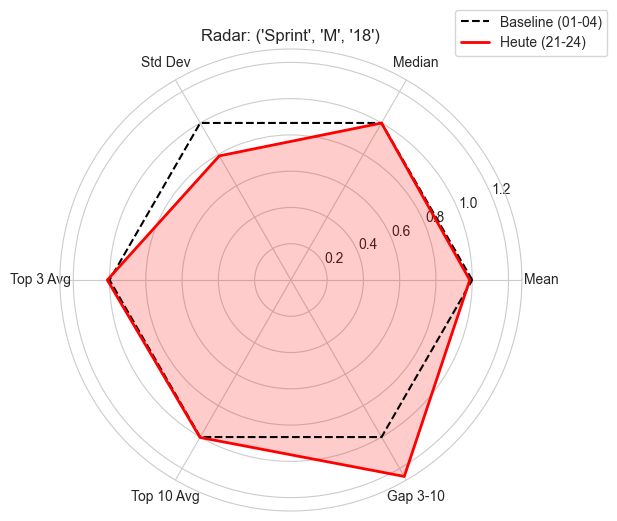

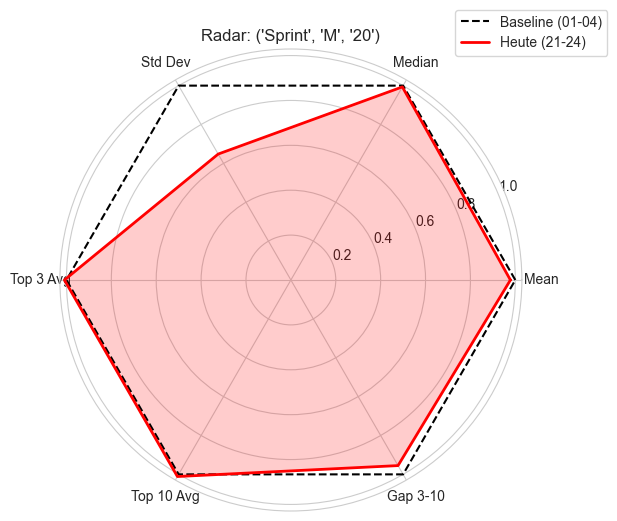

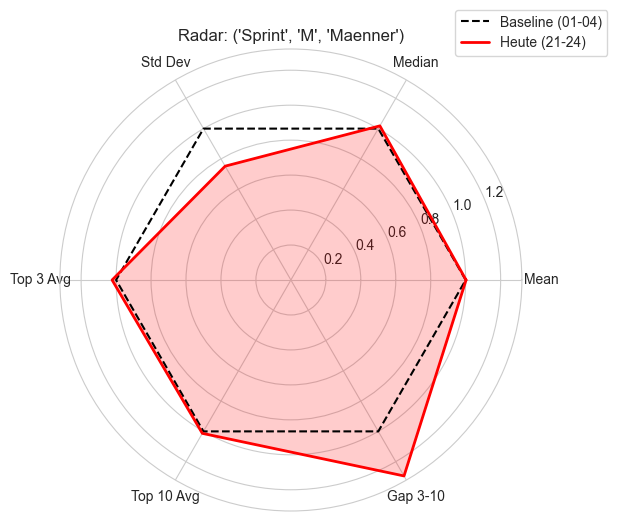

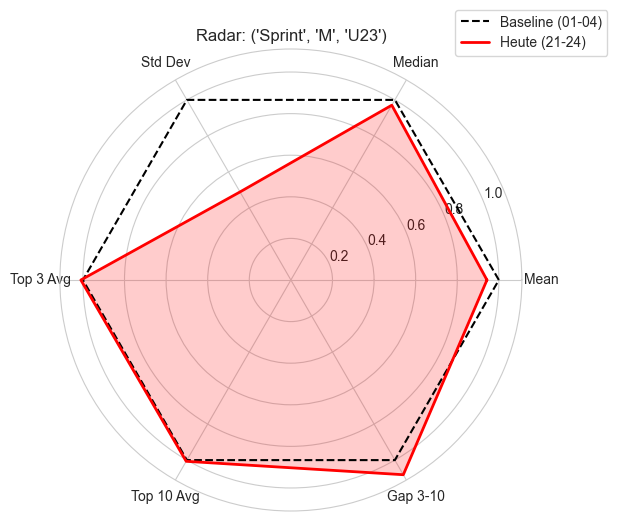

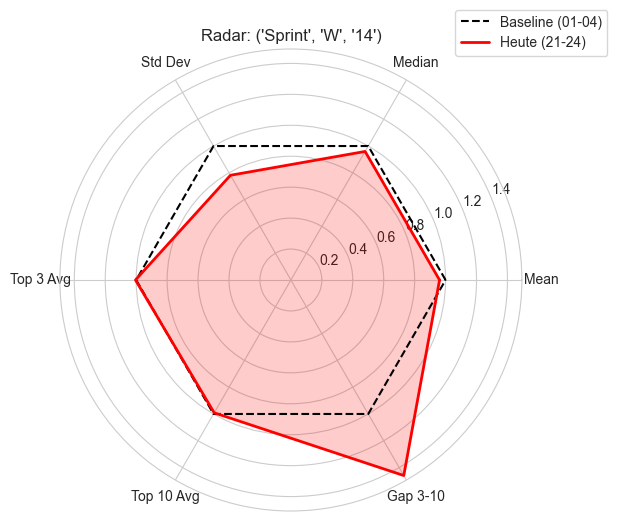

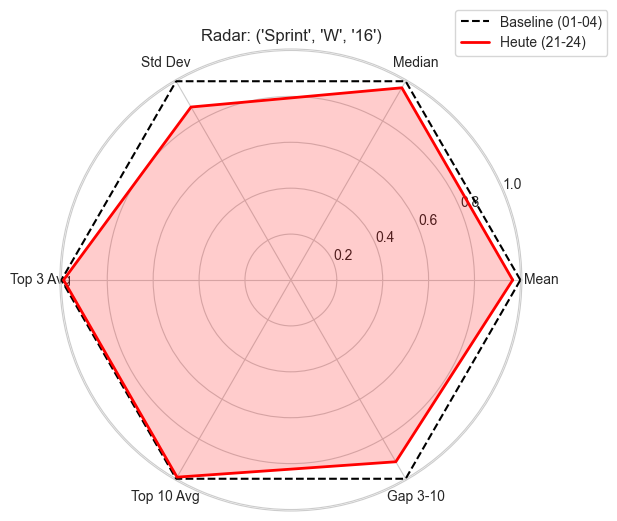

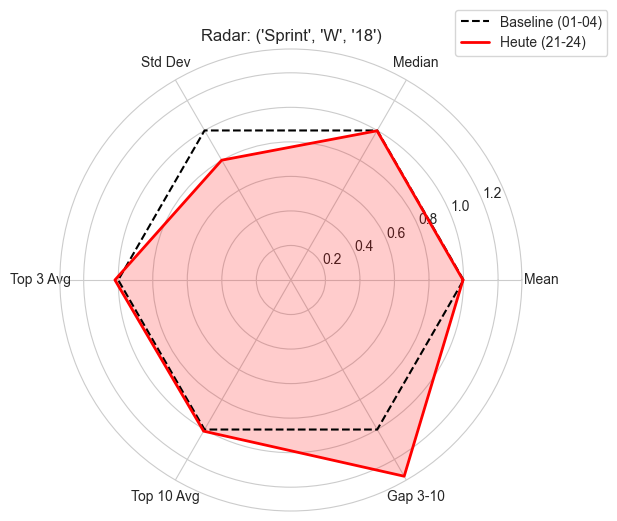

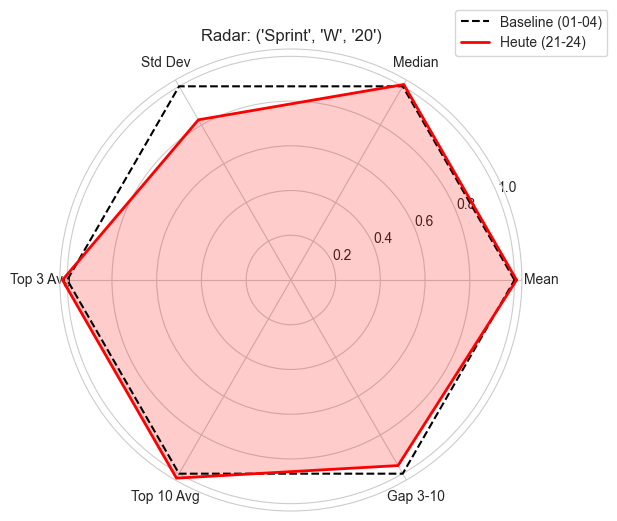

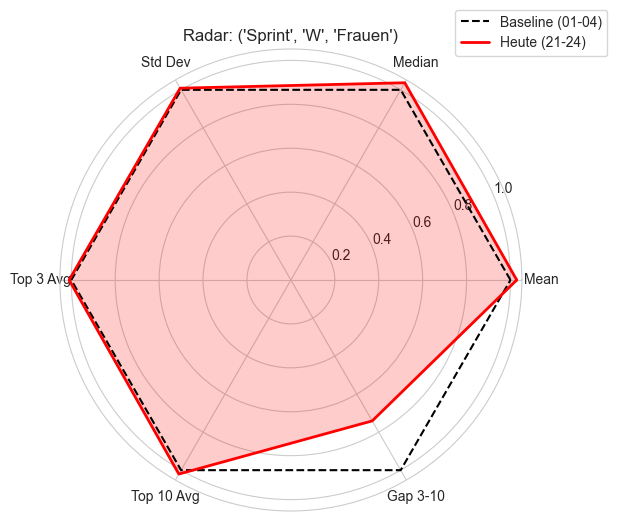

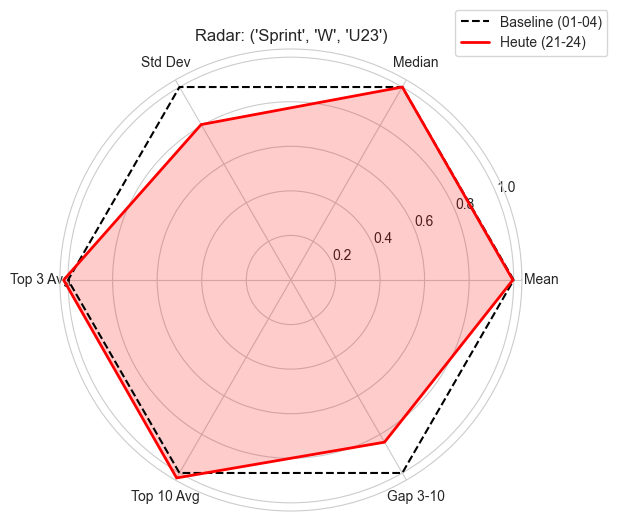

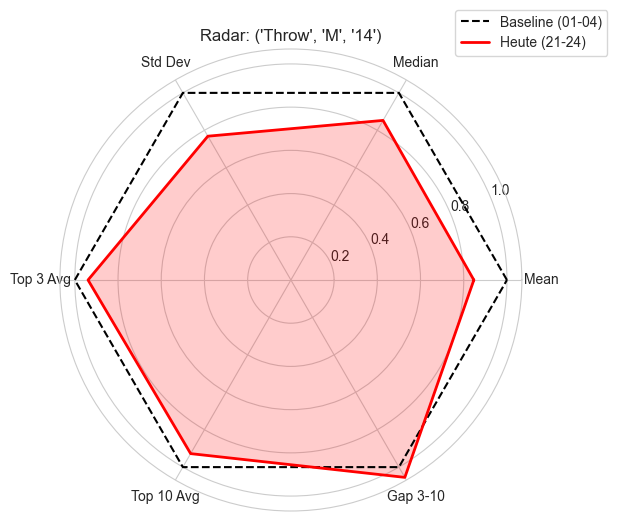

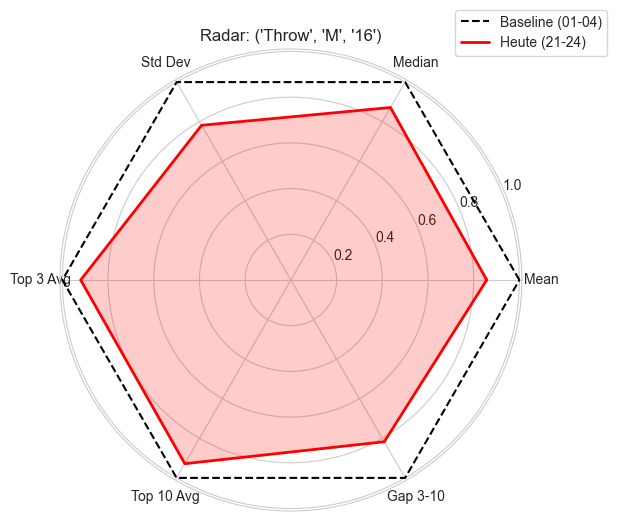

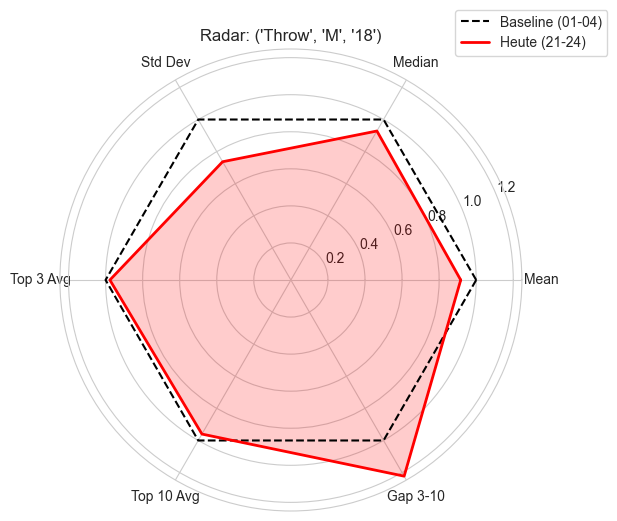

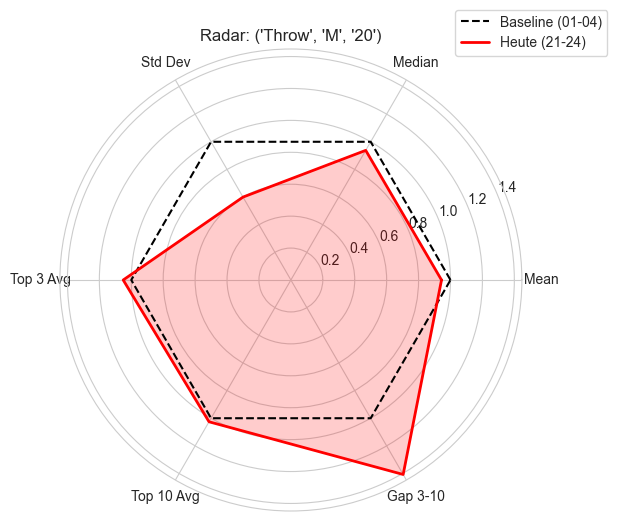

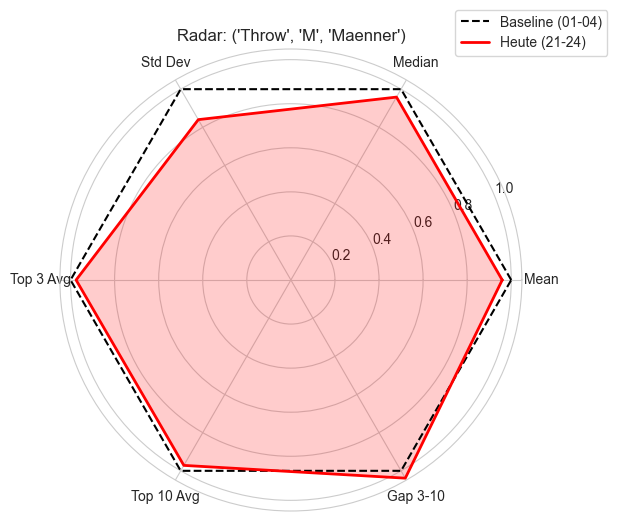

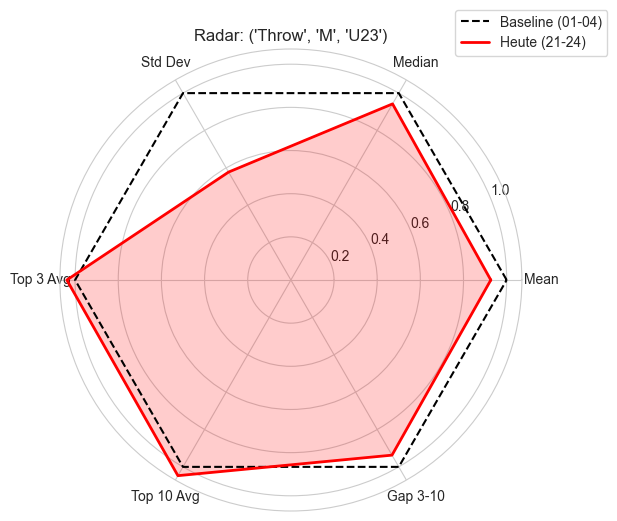

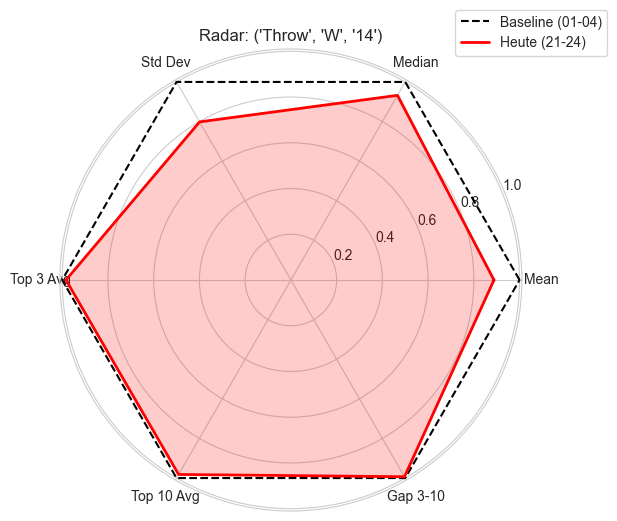

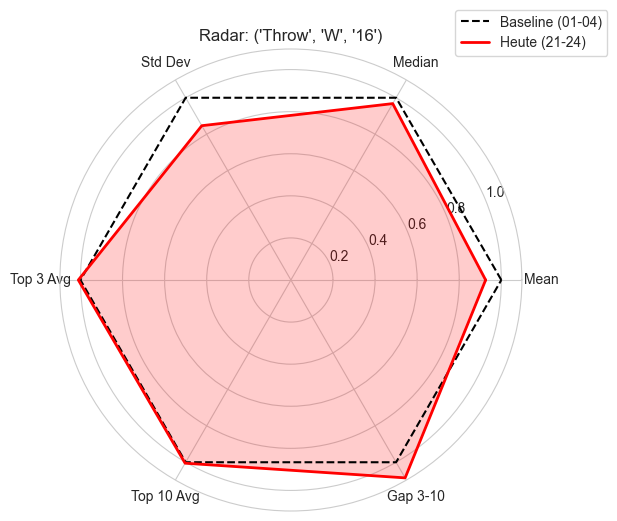

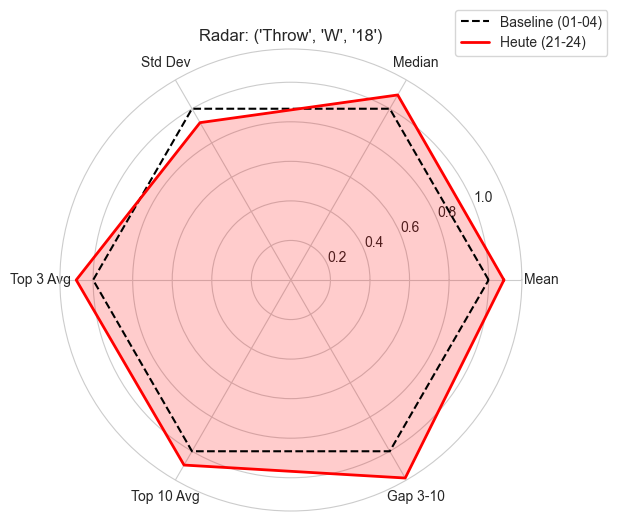

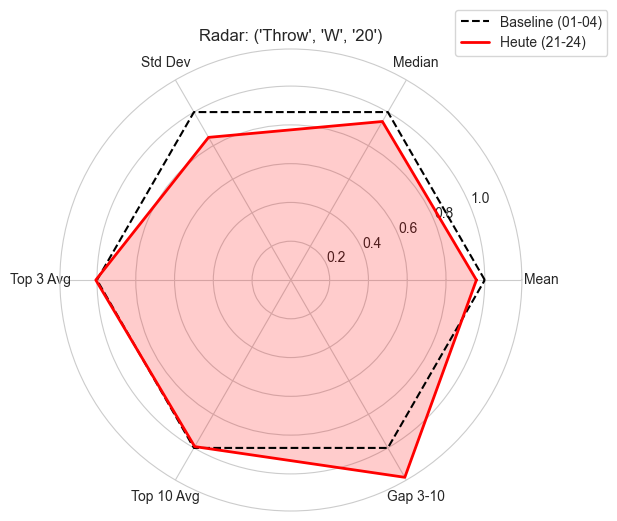

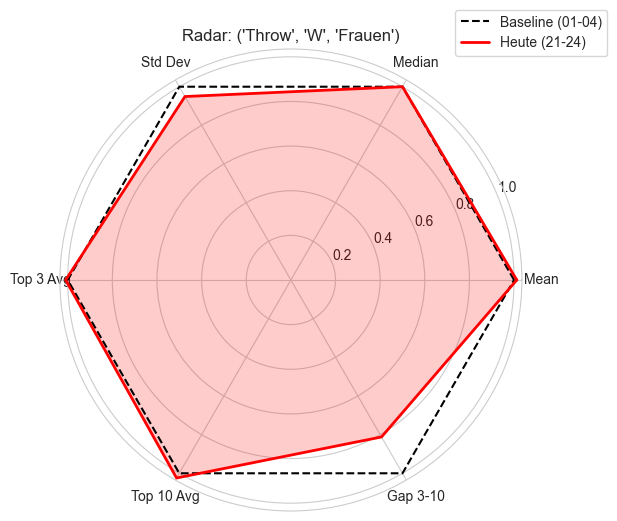

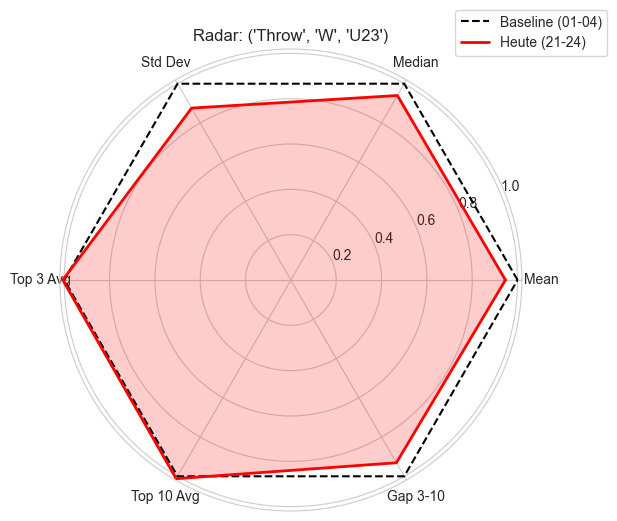

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os

# Pfad definieren
path = "/Users/erik/Library/CloudStorage/OneDrive-Persönlich/Tübingen Studium/1. Semester/Data Literacy/Project/Data-Literacy/data_csv"

# Verzeichnis wechseln
os.chdir(path)

# Überprüfen, ob es geklappt hat
print("Aktuelles Verzeichnis:", os.getcwd())

# Jetzt kannst du die Datei einfach mit dem Namen laden:
# data = load_data("final_Data_iaaf_scores_neu.csv")
# --- 1. UTILITY FUNKTIONEN (Dein Git-Strukturcode) ---
MEASUREMENT_TYPE = {
    "time": ['100 m', '200 m', '400 m', '800 m', '1500 m', '3000 m', '5000 m', '10 km', 'Halbmarathon', 'Marathon', '100 km', '100 m Huerden', '400 m Huerden', '3000 m Hindernis', '110 m Huerden', '2000 m Hindernis', '300 m', '1000 m', '5 km', '3000 m Gehen', '50 km Gehen', '10 000 m Gehen', '1500 m Hindernis', '10 000 m'],
    "meter": ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung', 'Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf'],
    "points": ['Siebenkampf', 'Zehnkampf']
}

mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m', '10 km', 'Marathon', '2000 m Hindernis', '3000 m Hindernis']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '100 m Huerden', '110 m Huerden', '400 m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']},
    **{d: 'Combined' for d in ['Zehnkampf', 'Siebenkampf']}
}

def convert_time_to_seconds(value):
    if pd.isna(value): return None
    value = str(value).replace(',', '.')
    parts = value.split(':')
    try:
        if len(parts) == 1: return float(parts[0])
        elif len(parts) == 2: return int(parts[0]) * 60 + float(parts[1])
        elif len(parts) == 3: return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    except: return None
    return None

def load_data(path_file):
    df = pd.read_csv(path_file, sep=";")
    def convert_leist(row):
        d, l = row['disziplin'], row['leistung']
        if d in MEASUREMENT_TYPE['time']: return convert_time_to_seconds(l)
        if d in MEASUREMENT_TYPE['meter']: return float(str(l).replace(',', '.')) if pd.notna(l) else None
        if d in MEASUREMENT_TYPE['points']: return float(str(l).replace('.', '')) if pd.notna(l) else None
        return l
    df['leistung_num'] = df.apply(convert_leist, axis=1)
    return df

# --- 2. VERARBEITUNG ---
# Lade die Datei (Pfad anpassen falls nötig)
data_all = load_data("final_Data_iaaf_scores_neu.csv")

# Ranking & Gruppen
data_all['disziplingruppe'] = data_all['disziplin'].map(mapping_dict)
data_all = data_all.sort_values(["jahr", "disziplin", "geschlecht", "altersklasse", "iaaf_score"], ascending=[True, True, True, True, False])
data_all['rank'] = data_all.groupby(["jahr", "disziplin", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

# --- 3. RADAR METRIKEN ---
def get_radar_metrics(data):
    if len(data) < 10: return pd.Series([np.nan]*6)
    t3 = data[data['rank'] <= 3]['iaaf_score'].mean()
    t10 = data[data['rank'] <= 10]['iaaf_score'].mean()
    r3_10 = data[data['rank'].between(3, 10)]['iaaf_score'].mean()
    return pd.Series({
        'Mean': data['iaaf_score'].mean(), 'Median': data['iaaf_score'].median(),
        'Std Dev': data['iaaf_score'].std(), 'Top 3 Avg': t3,
        'Top 10 Avg': t10, 'Gap 3-10': t3 - r3_10
    })

# Perioden-Vergleich
m_old = data_all[data_all['jahr'].between(2001, 2004)].groupby(['disziplingruppe', 'geschlecht', 'altersklasse']).apply(get_radar_metrics).dropna()
m_new = data_all[data_all['jahr'].between(2021, 2024)].groupby(['disziplingruppe', 'geschlecht', 'altersklasse']).apply(get_radar_metrics).dropna()

# --- 4. PLOTTING FUNKTION ---
def draw_radar(idx):
    old, new = m_old.loc[idx], m_new.loc[idx]
    labels = old.index.tolist()
    # Normierung: Baseline = 1.0. Std Dev invertiert (kleiner = besser = weiter außen)
    values = [new[c]/old[c] if c != 'Std Dev' else old[c]/new[c] for c in labels]
    
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    values += values[:1]; angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, [1.0]*len(angles), color='black', ls='--', label='Baseline (01-04)')
    ax.plot(angles, values, color='red', lw=2, label='Heute (21-24)')
    ax.fill(angles, values, color='red', alpha=0.2)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels)
    plt.title(f"Radar: {idx}")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

# Ausführen für alle verfügbaren Gruppen
for group_idx in m_new.index:
    if group_idx in m_old.index:
        draw_radar(group_idx)